# kMeans

In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [5]:
X, y = make_blobs(
    n_samples = 1000,
    n_features = 2,
    centers = 4,
    random_state = 42
)

<Axes: >

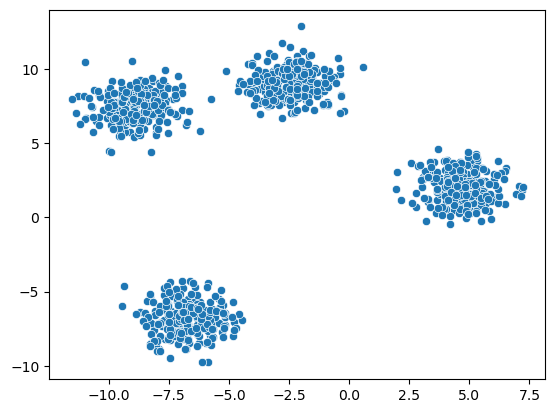

In [10]:
# Visualize
sns.scatterplot(x=X[:,0],y=X[:,1])

In [11]:
from sklearn.cluster import KMeans

In [12]:
K = 4

kmeans = KMeans(
    n_clusters = K,
    random_state = 42
)

In [14]:
labels = kmeans.fit_predict(X)

<Axes: >

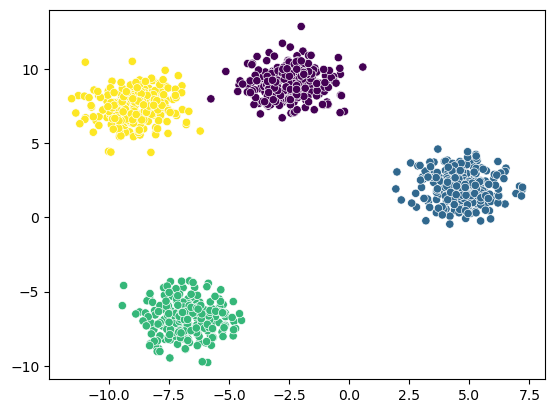

In [15]:
sns.scatterplot(x=X[:,0],y=X[:,1], c=y)

### Choose our k value - elbow method, silhoutte score

In [18]:
# elbow method

wcss = []
for k in range(1,21):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

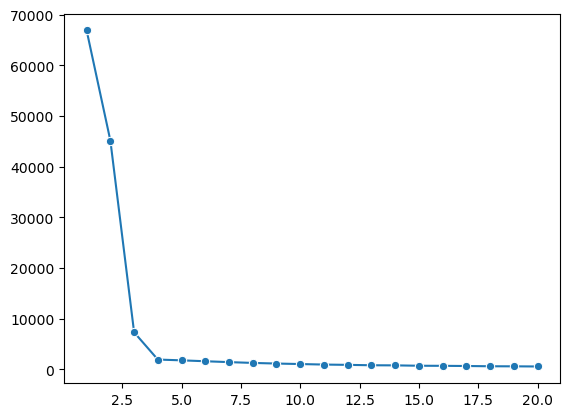

In [19]:
sns.lineplot(x=range(1,21),y=wcss,marker='o')

This is the manaul way to implement elbow method , clearly k = 4 is the calculated k by this.
To implement elbow method we can also use knee module.

In [20]:
!pip install kneed

In [21]:
from kneed import KneeLocator

In [23]:
knee = KneeLocator(range(1,21),wcss, curve = "convex", direction = "decreasing")

In [25]:
print("optimal k ->", knee.elbow)

optimal k -> 4


### Silhoutte score

In [27]:
from sklearn.metrics import silhouette_score

In [28]:
ss = []

for k in range(2,21):
    kmeans = KMeans(n_clusters = k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)

<Axes: >

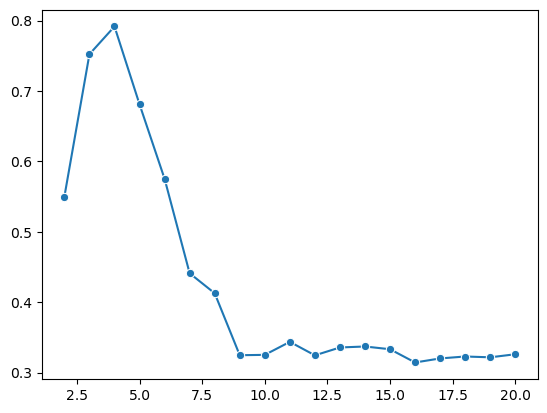

In [30]:
# plot
sns.lineplot(x=range(2,21),y = ss,marker = 'o')

Highest ss at 4